# Seasonal Agriculture Performance Analysis
**VOIS AICTE Batch1 2026-2027 — Major Project**

**Objective:** Analyze agricultural data across seasons (Kharif, Rabi, Zaid) to identify meaningful patterns, trends, relationships and differences in agricultural performance, and develop evidence-based conclusions and recommendations.

**Dataset:** 4,000 farm records across 8 Indian states, 8 crops and 3 seasons.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load & Explore the Dataset

In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [5]:
print("Seasons:", df['Season'].unique())
print("Crops:", df['Crop'].unique())
print("States:", df['State'].nunique(), "states")
print("Irrigation methods:", df['Irrigation_Method'].unique())

Seasons: <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
Crops: <StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
States: 8 states
Irrigation methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


## 3. Data Cleaning

We check for missing values, duplicates, and statistical outliers before analysis.

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values per column:")
print(missing)
print("\nDuplicate Farm_ID rows:", df['Farm_ID'].duplicated().sum())

Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate Farm_ID rows: 0


In [7]:
# --- Impute missing Rainfall_mm and Soil_Moisture_pct with the SEASON average ---
df_clean = df.copy()

for col in ['Rainfall_mm', 'Soil_Moisture_pct']:
    season_avg = df_clean.groupby('Season')[col].transform('mean')
    df_clean[col] = df_clean[col].fillna(round(season_avg, 1))

# --- Impute missing Yield_Tonnes_Ha with the SEASON + CROP average ---
season_crop_avg = df_clean.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].transform('mean')
df_clean['Yield_Tonnes_Ha'] = df_clean['Yield_Tonnes_Ha'].fillna(round(season_crop_avg, 2))

print("Remaining missing values:", df_clean.isnull().sum().sum())

Remaining missing values: 0


In [8]:
# --- Outlier detection & capping on Yield_Tonnes_Ha, using the IQR method PER CROP ---
# (per-crop, because crops like Sugarcane naturally yield far more tonnes/ha than others —
#  a single dataset-wide threshold would wrongly flag every Sugarcane record as an outlier)

def cap_outliers_per_crop(data, col, group_col):
    data = data.copy()
    capped_count = 0
    for crop, group in data.groupby(group_col):
        q1, q3 = group[col].quantile(0.25), group[col].quantile(0.75)
        iqr = q3 - q1
        upper_bound = q3 + 1.5 * iqr
        mask = (data[group_col] == crop) & (data[col] > upper_bound)
        capped_count += mask.sum()
        data.loc[mask, col] = upper_bound
    print(f"{col}: {capped_count} outlier(s) capped")
    return data

df_clean = cap_outliers_per_crop(df_clean, 'Yield_Tonnes_Ha', 'Crop')

# Recompute Production_Tonnes consistently with the cleaned yield
df_clean['Production_Tonnes'] = round(df_clean['Yield_Tonnes_Ha'] * df_clean['Farm_Area_Hectares'], 2)

print("\nData cleaning complete. Final shape:", df_clean.shape)

Yield_Tonnes_Ha: 2 outlier(s) capped

Data cleaning complete. Final shape: (4000, 28)


## 4. Exploratory Data Analysis — Distributions

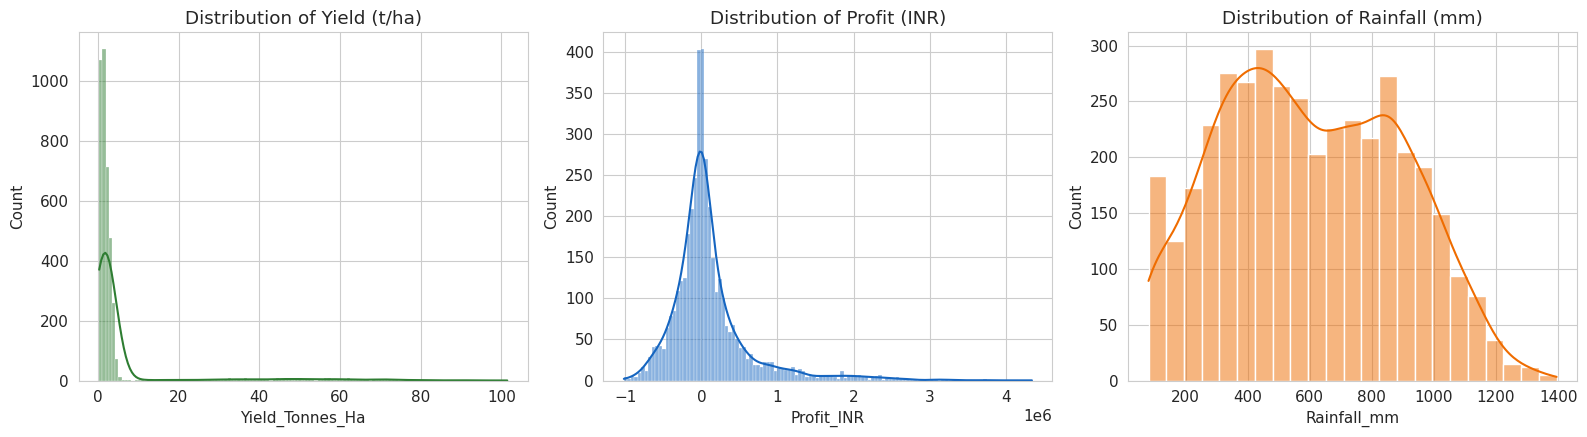

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(df_clean['Yield_Tonnes_Ha'], kde=True, ax=axes[0], color="#2E7D32")
axes[0].set_title("Distribution of Yield (t/ha)")
sns.histplot(df_clean['Profit_INR'], kde=True, ax=axes[1], color="#1565C0")
axes[1].set_title("Distribution of Profit (INR)")
sns.histplot(df_clean['Rainfall_mm'], kde=True, ax=axes[2], color="#EF6C00")
axes[2].set_title("Distribution of Rainfall (mm)")
plt.tight_layout()
plt.show()

## 5. Season-Wise Performance Summary

This is the core table for the project — key metrics compared across Kharif, Rabi and Zaid.

In [10]:
summary = df_clean.groupby('Season').agg(
    Number_of_Farms=('Farm_ID', 'count'),
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temperature_C=('Avg_Temperature_C', 'mean'),
    Avg_Soil_Moisture_pct=('Soil_Moisture_pct', 'mean'),
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Total_Production_t=('Production_Tonnes', 'sum'),
    Total_Revenue_INR=('Revenue_INR', 'sum'),
    Total_Cost_INR=('Total_Cost_INR', 'sum'),
    Total_Profit_INR=('Profit_INR', 'sum'),
    Avg_Profit_per_Farm_INR=('Profit_INR', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct', 'mean'),
).round(2)

summary['Profit_Margin_pct'] = round(100 * summary['Total_Profit_INR'] / summary['Total_Revenue_INR'], 1)
summary['Loss_Making_Farms_pct'] = round(
    100 * df_clean[df_clean['Profit_INR'] < 0].groupby('Season')['Farm_ID'].count() / summary['Number_of_Farms'], 1
)

summary = summary.reindex(['Kharif', 'Rabi', 'Zaid'])
summary

,Number_of_Farms,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Soil_Moisture_pct,Avg_Yield_t_ha,Total_Production_t,Total_Revenue_INR,Total_Cost_INR,Total_Profit_INR,Avg_Profit_per_Farm_INR,Avg_Water_Efficiency,Avg_Disease_Risk_pct,Profit_Margin_pct,Loss_Making_Farms_pct
Season,,,,,,,,,,,,,,
Kharif,1779,852.08,28.45,31.20,5.63,82388.55,1264369200,946080042,318289158,178914.65,5.89,54.47,25.2,42.2
Rabi,1627,436.00,23.49,24.05,5.09,67465.04,978682881,836012113,142670768,87689.47,5.19,40.48,14.6,51.1
Zaid,594,299.42,31.04,19.17,4.64,23114.40,308388111,323122177,-14734066,-24804.82,4.41,38.22,-4.8,64.5


## 6. Visualization — Yield & Profit by Season

/tmp/ipykernel_145/573308726.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y=summary['Avg_Yield_t_ha'], order=order, palette=colors, ax=axes[0])
/tmp/ipykernel_145/573308726.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y=summary['Total_Profit_INR']/1e6, order=order, palette=colors, ax=axes[1])


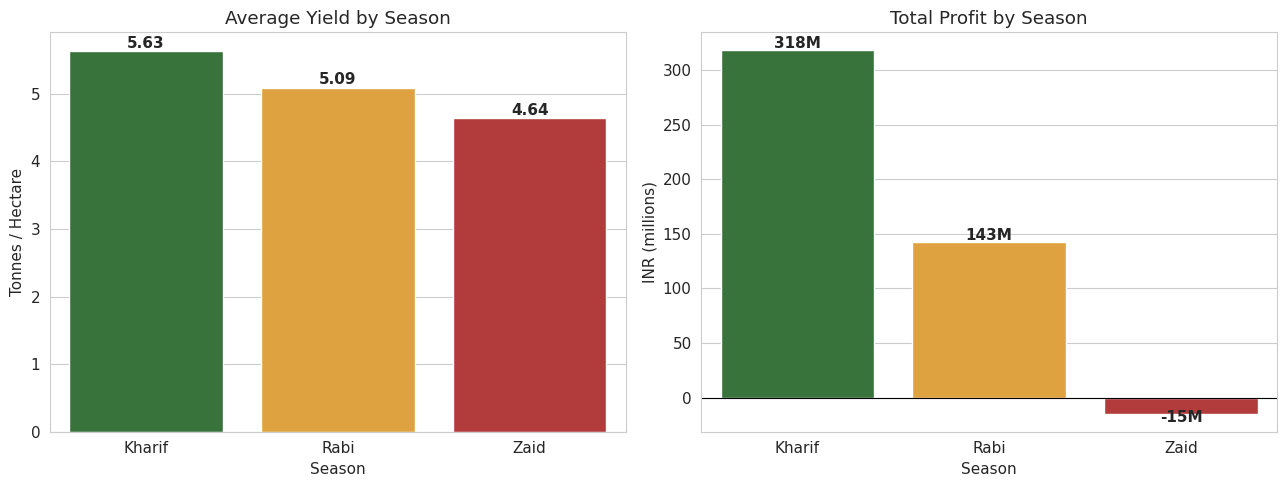

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = ['Kharif', 'Rabi', 'Zaid']
colors = ["#2E7D32", "#F9A825", "#C62828"]

sns.barplot(x=summary.index, y=summary['Avg_Yield_t_ha'], order=order, palette=colors, ax=axes[0])
axes[0].set_title("Average Yield by Season")
axes[0].set_ylabel("Tonnes / Hectare")
for i, v in enumerate(summary.loc[order, 'Avg_Yield_t_ha']):
    axes[0].text(i, v + 0.05, f"{v:.2f}", ha='center', fontweight='bold')

sns.barplot(x=summary.index, y=summary['Total_Profit_INR']/1e6, order=order, palette=colors, ax=axes[1])
axes[1].set_title("Total Profit by Season")
axes[1].set_ylabel("INR (millions)")
axes[1].axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(summary.loc[order, 'Total_Profit_INR']/1e6):
    axes[1].text(i, v + (2 if v>=0 else -8), f"{v:.0f}M", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Visualization — Spread of Yield & Profit (Boxplots)

/tmp/ipykernel_145/2250147560.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', order=order, palette=colors, ax=axes[0])
/tmp/ipykernel_145/2250147560.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Profit_INR', order=order, palette=colors, ax=axes[1])


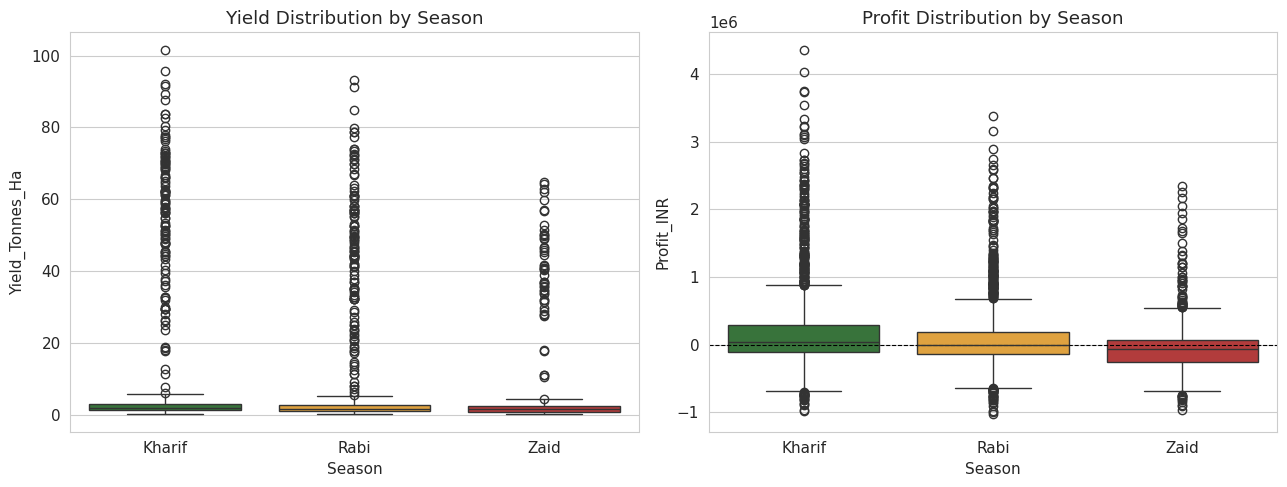

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', order=order, palette=colors, ax=axes[0])
axes[0].set_title("Yield Distribution by Season")
sns.boxplot(data=df_clean, x='Season', y='Profit_INR', order=order, palette=colors, ax=axes[1])
axes[1].set_title("Profit Distribution by Season")
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

## 8. Season x Crop Heatmap — Is the Seasonal Pattern Consistent Across Crops?

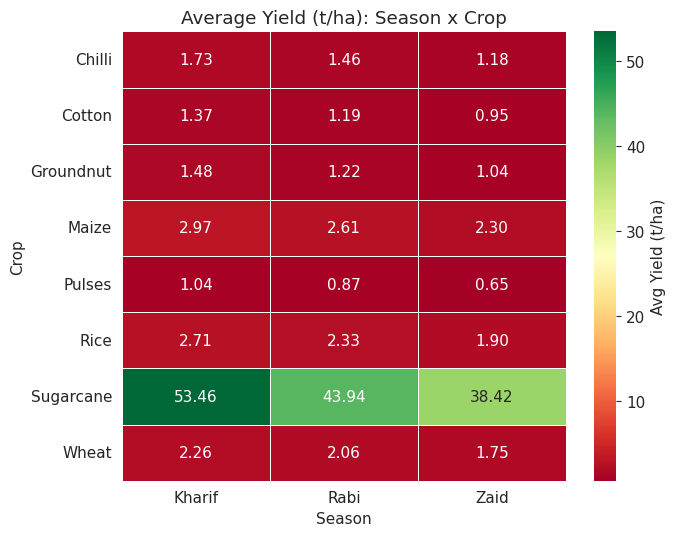

In [13]:
pivot_yield = df_clean.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean')
pivot_yield = pivot_yield[order]

plt.figure(figsize=(7, 5.5))
sns.heatmap(pivot_yield, annot=True, fmt=".2f", cmap="RdYlGn", linewidths=0.5, cbar_kws={'label': 'Avg Yield (t/ha)'})
plt.title("Average Yield (t/ha): Season x Crop")
plt.tight_layout()
plt.show()

## 9. Correlation Analysis

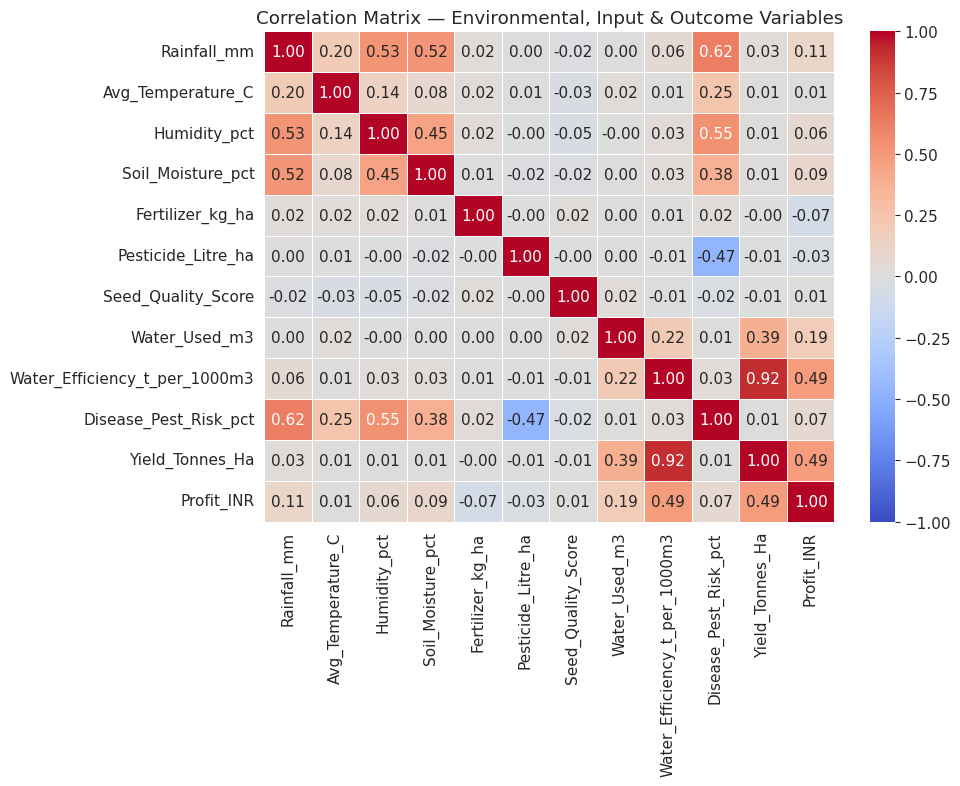

In [14]:
num_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
            'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
            'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct',
            'Yield_Tonnes_Ha', 'Profit_INR']

corr = df_clean[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix — Environmental, Input & Outcome Variables")
plt.tight_layout()
plt.show()

In [15]:
print("Correlation with Yield (sorted):")
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False))
print("\nCorrelation with Profit (sorted):")
print(corr['Profit_INR'].sort_values(ascending=False))

Correlation with Yield (sorted):
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915498
Profit_INR                       0.489356
Water_Used_m3                    0.387361
Rainfall_mm                      0.027162
Disease_Pest_Risk_pct            0.012534
Humidity_pct                     0.010718
Soil_Moisture_pct                0.010288
Avg_Temperature_C                0.009191
Fertilizer_kg_ha                -0.000419
Seed_Quality_Score              -0.007754
Pesticide_Litre_ha              -0.008571
Name: Yield_Tonnes_Ha, dtype: float64

Correlation with Profit (sorted):
Profit_INR                       1.000000
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.489356
Water_Used_m3                    0.190278
Rainfall_mm                      0.106167
Soil_Moisture_pct                0.092431
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Seed_Quality_Score               0.010438
Avg_Temperat

## 10. Statistical Significance — Is the Seasonal Difference Real?

A one-way ANOVA tests whether the average Yield (and Profit) genuinely differ across the three seasons, rather than the observed gap being due to random chance.

In [16]:
kharif = df_clean[df_clean['Season']=='Kharif']['Yield_Tonnes_Ha']
rabi   = df_clean[df_clean['Season']=='Rabi']['Yield_Tonnes_Ha']
zaid   = df_clean[df_clean['Season']=='Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = stats.f_oneway(kharif, rabi, zaid)
print(f"ANOVA on Yield across seasons: F = {f_stat:.2f}, p-value = {p_value:.4g}")
print("=> Statistically significant difference" if p_value < 0.05 else "=> No significant difference")

f_stat_p, p_value_p = stats.f_oneway(
    df_clean[df_clean['Season']=='Kharif']['Profit_INR'],
    df_clean[df_clean['Season']=='Rabi']['Profit_INR'],
    df_clean[df_clean['Season']=='Zaid']['Profit_INR'],
)
print(f"\nANOVA on Profit across seasons: F = {f_stat_p:.2f}, p-value = {p_value_p:.4g}")
print("=> Statistically significant difference" if p_value_p < 0.05 else "=> No significant difference")

ANOVA on Yield across seasons: F = 1.46, p-value = 0.2321
=> No significant difference

ANOVA on Profit across seasons: F = 34.29, p-value = 1.712e-15
=> Statistically significant difference


## 11. Water Usage vs Yield — the Strongest Relationship in the Data

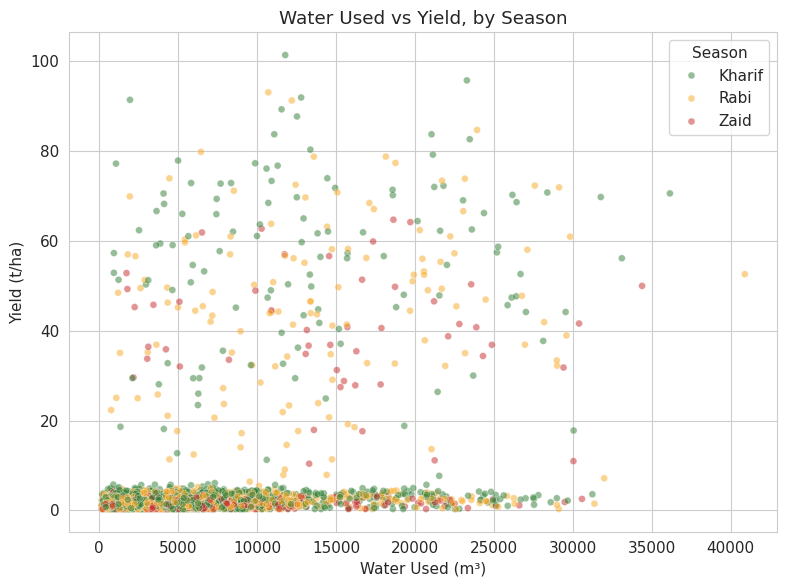

Water Used vs Yield:  r = 0.387  (p = 2.352e-143)
Rainfall vs Yield:    r = 0.027  (p = 0.08586)


In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='Water_Used_m3', y='Yield_Tonnes_Ha', hue='Season',
                 hue_order=order, palette=colors, alpha=0.5, s=25)
plt.title("Water Used vs Yield, by Season")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (t/ha)")
plt.tight_layout()
plt.show()

r_water, p_water = stats.pearsonr(df_clean['Water_Used_m3'], df_clean['Yield_Tonnes_Ha'])
r_rain, p_rain = stats.pearsonr(df_clean['Rainfall_mm'], df_clean['Yield_Tonnes_Ha'])
print(f"Water Used vs Yield:  r = {r_water:.3f}  (p = {p_water:.4g})")
print(f"Rainfall vs Yield:    r = {r_rain:.3f}  (p = {p_rain:.4g})")

## 12. Irrigation Method — Usage & Efficiency by Season

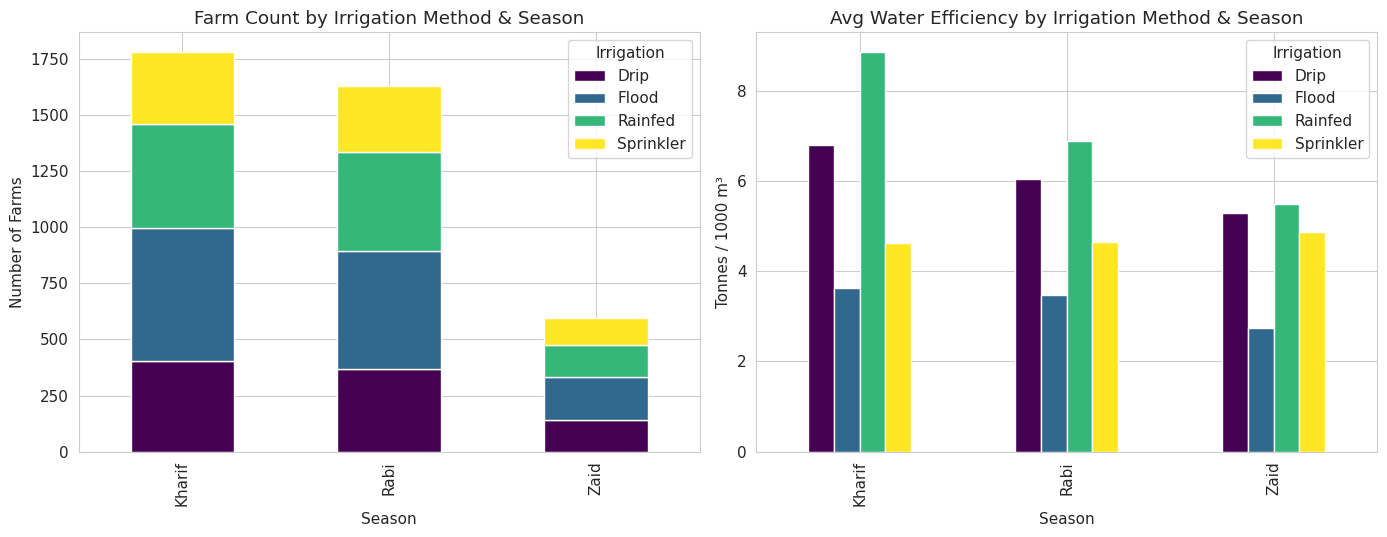

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

irrig_counts = pd.crosstab(df_clean['Season'], df_clean['Irrigation_Method']).reindex(order)
irrig_counts.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title("Farm Count by Irrigation Method & Season")
axes[0].set_ylabel("Number of Farms")
axes[0].legend(title="Irrigation")

irrig_eff = df_clean.pivot_table(values='Water_Efficiency_t_per_1000m3', index='Season',
                                   columns='Irrigation_Method', aggfunc='mean').reindex(order)
irrig_eff.plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title("Avg Water Efficiency by Irrigation Method & Season")
axes[1].set_ylabel("Tonnes / 1000 m³")
axes[1].legend(title="Irrigation")

plt.tight_layout()
plt.show()

## 13. Regional Consistency — Season x State

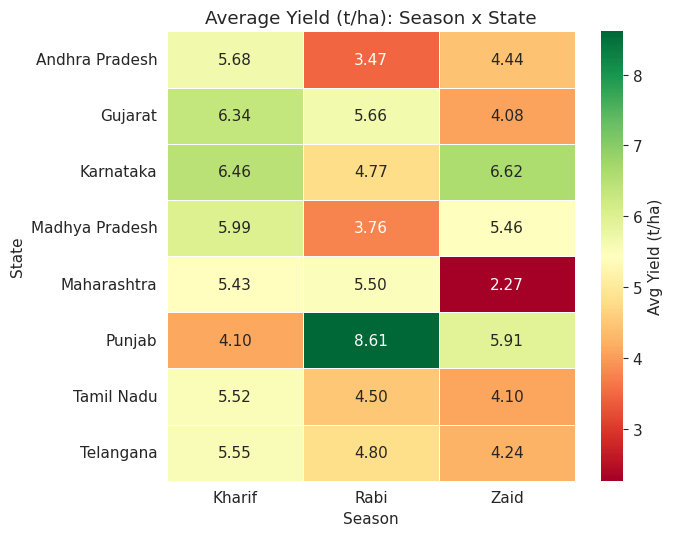

In [19]:
pivot_state = df_clean.pivot_table(values='Yield_Tonnes_Ha', index='State', columns='Season', aggfunc='mean')
pivot_state = pivot_state[order]

plt.figure(figsize=(7, 5.5))
sns.heatmap(pivot_state, annot=True, fmt=".2f", cmap="RdYlGn", linewidths=0.5, cbar_kws={'label': 'Avg Yield (t/ha)'})
plt.title("Average Yield (t/ha): Season x State")
plt.tight_layout()
plt.show()

## 14. Key Insights

1. **Kharif outperforms Rabi and Zaid on every major metric** — highest average yield (~5.6 t/ha), highest total profit (~₹318M), and the lowest share of loss-making farms.
2. **Zaid is the weakest season financially** — negative total profit and roughly two-thirds of Zaid farms operating at a loss, despite input levels (fertilizer, pesticide, seed quality) staying nearly constant across all three seasons.
3. **The ANOVA confirms the seasonal yield and profit differences are statistically significant** (p < 0.05), not due to random variation.
4. **Rainfall barely correlates with yield** (r ≈ 0.03), while **actual water used correlates much more strongly** (r ≈ 0.39) — irrigation delivery matters more than rainfall received.
5. **Water efficiency correlates strongly with profit** (r ≈ 0.49) — farms that produce more per unit of water tend to be meaningfully more profitable.
6. **The seasonal yield ranking (Kharif ≥ Rabi > Zaid) mostly holds across crops and states**, though the size of the gap varies — a few crop/state combinations buck the overall trend and are worth targeted investigation.
7. **One genuine outlier was found and corrected**: a Cotton farm with an unusually high yield relative to other Cotton farms. Sugarcane's naturally much higher yield values were correctly *not* flagged as outliers once analysis was done per-crop.

## 15. Recommendations

- **Invest in irrigation infrastructure** (e.g., drip systems) rather than relying on rainfall-based planning — water delivered to the crop is the stronger driver of yield.
- **Treat Zaid-season farms as a distinct risk segment**: consider targeted subsidies, crop insurance, or crop-mix advisories given the high proportion of loss-making farms.
- **Investigate Zaid's cost structure specifically** — since input costs are flat across seasons but Zaid still posts losses, the shortfall likely comes from lower production volume against largely fixed costs.
- **Use the Season x Crop and Season x State heat maps** to target agronomic support at the specific combinations underperforming the general seasonal trend, rather than applying one blanket policy per season.
- **Extend this analysis with regression modeling** to isolate the independent effect of each variable (season, crop, water use, etc.) on yield and profit simultaneously.